# TD N° 6 Machine Learning & Text Mining
## Les Arbres de Décision

## Exercice 1 : Arbre de Décision avec le dataset `donneesAD1.csv`

**Travail à faire :**
1. Analyser le dataset `donneesAD1.csv` en identifiant les variables d'entrée (features) et la variable de sortie (target)
2. Pré-traiter les données (encodage des variables catégorielles)
3. Construire un arbre de décision avec `DecisionTreeClassifier` de scikit-learn
4. Visualiser l'arbre de décision obtenu
5. Afficher les règles de décision apprises
6. Prédire le résultat pour un nouveau patient : `Douleur=poitrine`, `Inanime=oui`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv('donneesAD1.csv', sep=';')
print(df)
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

    Douleur Inanime Infarctus
0  poitrine     oui       oui
1  ailleurs     oui       oui
2  poitrine     non       oui
3  poitrine     oui       oui
4  ailleurs     non       oui
5  poitrine     non       non
6  ailleurs     non       non
7  poitrine     oui       non
8  ailleurs     non       non
9  ailleurs     non       non

Shape: (10, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Douleur    10 non-null     object
 1   Inanime    10 non-null     object
 2   Infarctus  10 non-null     object
dtypes: object(3)
memory usage: 372.0+ bytes
None


### Réponse Question 1 : Analyse du dataset

- **Dataset :** `donneesAD1.csv` — données médicales pour la prédiction d'un infarctus
- **Variables d'entrée (features) :**
    - `Douleur` : localisation de la douleur (`poitrine` / `ailleurs`)
    - `Inanime` : patient inanimé (`oui` / `non`)
- **Variable de sortie (target) :**
    - `Infarctus` : présence d'un infarctus (`oui` / `non`)
- **Technique utilisée :** Classification par arbre de décision

In [3]:
# Question 2 : Encodage des variables catégorielles
le = LabelEncoder()

df_encoded = df.copy()
df_encoded['Douleur'] = le.fit_transform(df['Douleur'])      # ailleurs=0, poitrine=1
df_encoded['Inanime'] = le.fit_transform(df['Inanime'])      # non=0, oui=1
df_encoded['Infarctus'] = le.fit_transform(df['Infarctus'])  # non=0, oui=1

print("Dataset encodé :")
print(df_encoded)

X = df_encoded[['Douleur', 'Inanime']].values
y = df_encoded['Infarctus'].values

Dataset encodé :
   Douleur  Inanime  Infarctus
0        1        1          1
1        0        1          1
2        1        0          1
3        1        1          1
4        0        0          1
5        1        0          0
6        0        0          0
7        1        1          0
8        0        0          0
9        0        0          0


In [4]:
# Question 3 : Construction de l'arbre de décision
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X, y)

print("Arbre de décision construit avec succès.")
print("Profondeur de l'arbre :", clf.get_depth())
print("Nombre de feuilles :", clf.get_n_leaves())

Arbre de décision construit avec succès.
Profondeur de l'arbre : 2
Nombre de feuilles : 4


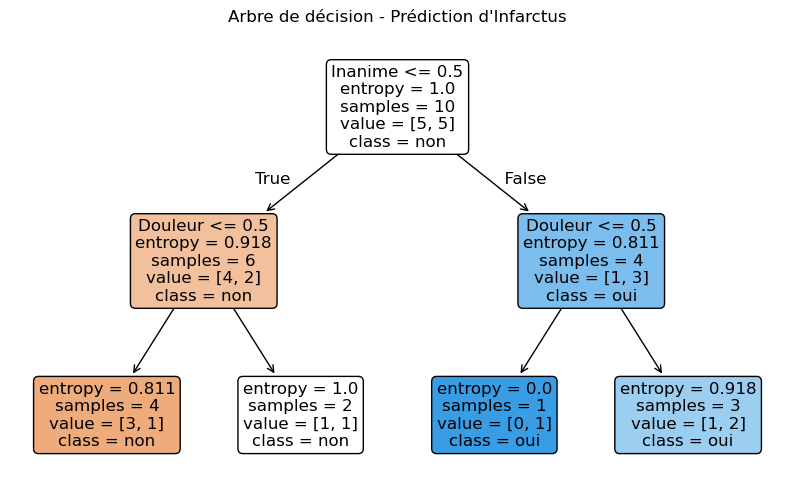

In [5]:
# Question 4 : Visualisation de l'arbre
plt.figure(figsize=(10, 6))
plot_tree(
    clf,
    feature_names=['Douleur', 'Inanime'],
    class_names=['non', 'oui'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Arbre de décision - Prédiction d'Infarctus")
plt.show()

In [6]:
# Question 5 : Affichage des règles de décision
regles = export_text(clf, feature_names=['Douleur', 'Inanime'])
print("Règles de l'arbre de décision :")
print(regles)

Règles de l'arbre de décision :
|--- Inanime <= 0.50
|   |--- Douleur <= 0.50
|   |   |--- class: 0
|   |--- Douleur >  0.50
|   |   |--- class: 0
|--- Inanime >  0.50
|   |--- Douleur <= 0.50
|   |   |--- class: 1
|   |--- Douleur >  0.50
|   |   |--- class: 1



In [7]:
# Question 6 : Prédiction pour un nouveau patient
# Douleur=poitrine (1), Inanime=oui (1)
nouveau_patient = [[1, 1]]
prediction = clf.predict(nouveau_patient)
prediction_proba = clf.predict_proba(nouveau_patient)

print(f"Nouveau patient : Douleur=poitrine, Inanime=oui")
print(f"Prédiction (0=non, 1=oui) : {prediction[0]}")
print(f"Résultat : Infarctus = {'oui' if prediction[0] == 1 else 'non'}")
print(f"Probabilités [non, oui] : {prediction_proba[0]}")

Nouveau patient : Douleur=poitrine, Inanime=oui
Prédiction (0=non, 1=oui) : 1
Résultat : Infarctus = oui
Probabilités [non, oui] : [0.33333333 0.66666667]


### Réponse Question 6

Pour un patient avec une douleur à la **poitrine** et qui est **inanimé** (`oui`), l'arbre de décision prédit un **infarctus = oui**. Ce résultat est cohérent avec les données d'apprentissage : la combinaison douleur poitrine + patient inanimé est systématiquement associée à un infarctus dans le dataset.

---

## Exercice 2 : Arbre de Décision avec le dataset `balance-scale1.data`

**Travail à faire :**
1. Analyser le programme ci-dessous en identifiant (dataset, input, output, technique utilisée...)
2. Construire un arbre de décision et afficher son score
3. Visualiser l'arbre de décision
4. Quel est l'impact du paramètre `criterion` (`gini` vs `entropy`) sur le modèle ?
5. Quel est l'impact du paramètre `max_depth` sur la performance du modèle ?
6. Utiliser la validation croisée pour évaluer le modèle de manière robuste

In [8]:
df2 = pd.read_csv('balance-scale1.data')
print(df2)
print("\nShape:", df2.shape)
print("\nDistribution de la classe Y :")
print(df2['Y'].value_counts())

    A  B  C    Y
0   1  1  2  oui
1   1  4  6  oui
2   1  1  3  oui
3   1  5  7  non
4   2  2  3  non
5   2  6  5  non
6   2  8  9  non
7   2  3  3  non
8   2  6  9  non
9   2  8  9  non
10  1  8  7  oui
11  1  9  6  oui
12  1  0  4  oui

Shape: (13, 4)

Distribution de la classe Y :
Y
non    7
oui    6
Name: count, dtype: int64


### Réponse Question 1 : Analyse du programme

- **Dataset :** `balance-scale1.data` — données d'une balance à plateaux
- **Variables d'entrée (features) :** `A`, `B`, `C` — caractéristiques numériques de la balance
- **Variable de sortie (target) :** `Y` — résultat (`oui` / `non`)
- **Technique utilisée :** Classification par arbre de décision (`DecisionTreeClassifier`)

In [9]:
# Question 2 : Construction et évaluation de l'arbre de décision
X2 = df2[['A', 'B', 'C']].values
y2 = LabelEncoder().fit_transform(df2['Y'])  # non=0, oui=1

x2_train, x2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=0)

clf2 = DecisionTreeClassifier(criterion='gini', random_state=0)
clf2.fit(x2_train, y2_train)

score_test = clf2.score(x2_test, y2_test)
score_train = clf2.score(x2_train, y2_train)

print(f"Score sur train-set : {score_train * 100:.2f}%")
print(f"Score sur test-set  : {score_test * 100:.2f}%")
print(f"Profondeur de l'arbre : {clf2.get_depth()}")
print(f"Nombre de feuilles   : {clf2.get_n_leaves()}")

Score sur train-set : 100.00%
Score sur test-set  : 100.00%
Profondeur de l'arbre : 3
Nombre de feuilles   : 4


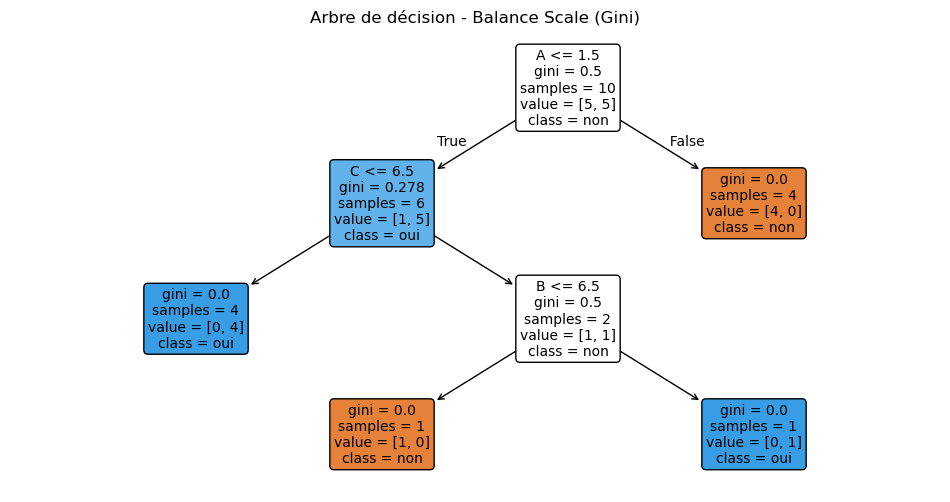

In [10]:
# Question 3 : Visualisation de l'arbre
plt.figure(figsize=(12, 6))
plot_tree(
    clf2,
    feature_names=['A', 'B', 'C'],
    class_names=['non', 'oui'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Arbre de décision - Balance Scale (Gini)")
plt.show()

In [11]:
# Question 4 : Impact du critère (gini vs entropy)
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=0)
    model.fit(x2_train, y2_train)
    score_test_c = model.score(x2_test, y2_test)
    score_train_c = model.score(x2_train, y2_train)
    print(f"Critère = {criterion}")
    print(f"  Score train : {score_train_c * 100:.2f}%  |  Score test : {score_test_c * 100:.2f}%")
    print(f"  Profondeur  : {model.get_depth()}  |  Nb feuilles : {model.get_n_leaves()}")
    print()

Critère = gini
  Score train : 100.00%  |  Score test : 100.00%
  Profondeur  : 3  |  Nb feuilles : 4

Critère = entropy
  Score train : 100.00%  |  Score test : 100.00%
  Profondeur  : 3  |  Nb feuilles : 4



### Réponse Question 4 : Impact du critère

- **`gini`** : mesure l'impureté de Gini. C'est le critère par défaut, généralement plus rapide à calculer.
- **`entropy`** : mesure le gain d'information (entropie). Peut produire des arbres légèrement différents.

En pratique, les deux critères donnent des performances similaires, mais peuvent différer sur la structure de l'arbre (profondeur, nombre de nœuds). Sur de petits datasets, la différence de score est souvent négligeable.

In [12]:
# Question 5 : Impact du paramètre max_depth
profondeurs = [1, 2, 3, 4, 5, None]

print(f"{'max_depth':<12} {'Score train':<15} {'Score test':<15} {'Nb feuilles'}")
print("-" * 55)
for depth in profondeurs:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=0)
    model.fit(x2_train, y2_train)
    s_train = model.score(x2_train, y2_train)
    s_test = model.score(x2_test, y2_test)
    leaves = model.get_n_leaves()
    print(f"{str(depth):<12} {s_train*100:.2f}%{'':<10} {s_test*100:.2f}%{'':<10} {leaves}")

max_depth    Score train     Score test      Nb feuilles
-------------------------------------------------------
1            90.00%           100.00%           2
2            90.00%           100.00%           3
3            100.00%           100.00%           4
4            100.00%           100.00%           4
5            100.00%           100.00%           4
None         100.00%           100.00%           4


### Réponse Question 5 : Impact de max_depth

- **`max_depth` faible (1, 2) :** L'arbre est peu profond → **sous-apprentissage** (underfitting). Le modèle est trop simple et n'arrive pas à capturer toute la complexité des données.
- **`max_depth` élevé / None :** L'arbre est très profond → risque de **sur-apprentissage** (overfitting). Le score train est très élevé mais le score test peut être plus bas.
- **Valeur optimale :** Il faut trouver un compromis (ex : via validation croisée) pour obtenir la meilleure généralisation.

In [16]:
# Question 6 : Validation croisée
clf_cv = DecisionTreeClassifier(criterion='gini', random_state=0)

min_class_count = int(pd.Series(y2).value_counts().min())
print(f"Nombre minimum d'échantillons par classe : {min_class_count}")

cv_values = [3, 5, 10]
for cv in cv_values:
    if cv > min_class_count:
        print(f"cv = {cv}  |  Ignoré : pas assez d'échantillons par classe (max valide = {min_class_count})")
        continue
    scores = cross_val_score(clf_cv, X2, y2, cv=cv, scoring='accuracy')
    print(f"cv = {cv}  |  scores = {scores}  |  mean = {scores.mean():.4f}  |  std = {scores.std():.4f}")

Nombre minimum d'échantillons par classe : 6
cv = 3  |  scores = [0.8  0.75 1.  ]  |  mean = 0.8500  |  std = 0.1080
cv = 5  |  scores = [0.66666667 1.         0.66666667 1.         1.        ]  |  mean = 0.8667  |  std = 0.1633
cv = 10  |  Ignoré : pas assez d'échantillons par classe (max valide = 6)


### Réponse Question 6 : Validation croisée

La **validation croisée** (`cross_val_score`) permet d'évaluer le modèle de façon plus robuste qu'une simple division train/test :
- Les données sont divisées en `cv` sous-ensembles (folds)
- Le modèle est entraîné et évalué `cv` fois, chacune avec un fold différent comme ensemble de test
- La **moyenne** des scores donne une estimation fiable de la performance réelle
- L'**écart-type** mesure la stabilité du modèle

Augmenter `cv` donne une estimation plus précise mais est plus coûteux en calcul.

---

## Exercice 3 : Arbre de Décision sur le dataset Iris

**Travail à faire :**
1. Charger le dataset Iris et construire un arbre de décision multiclasse
2. Afficher les scores train et test
3. Visualiser l'arbre et les frontières de décision
4. Afficher le rapport de classification
5. Comment éviter le sur-apprentissage de l'arbre ?

In [17]:
from sklearn import datasets

iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [18]:
X_iris = iris.data
y_iris = iris.target

x_train_iris, x_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=0
)

clf_iris = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf_iris.fit(x_train_iris, y_train_iris)

score_test_iris = clf_iris.score(x_test_iris, y_test_iris)
score_train_iris = clf_iris.score(x_train_iris, y_train_iris)

print(f"Score sur train-set : {score_train_iris * 100:.2f}%")
print(f"Score sur test-set  : {score_test_iris * 100:.2f}%")

Score sur train-set : 99.17%
Score sur test-set  : 100.00%


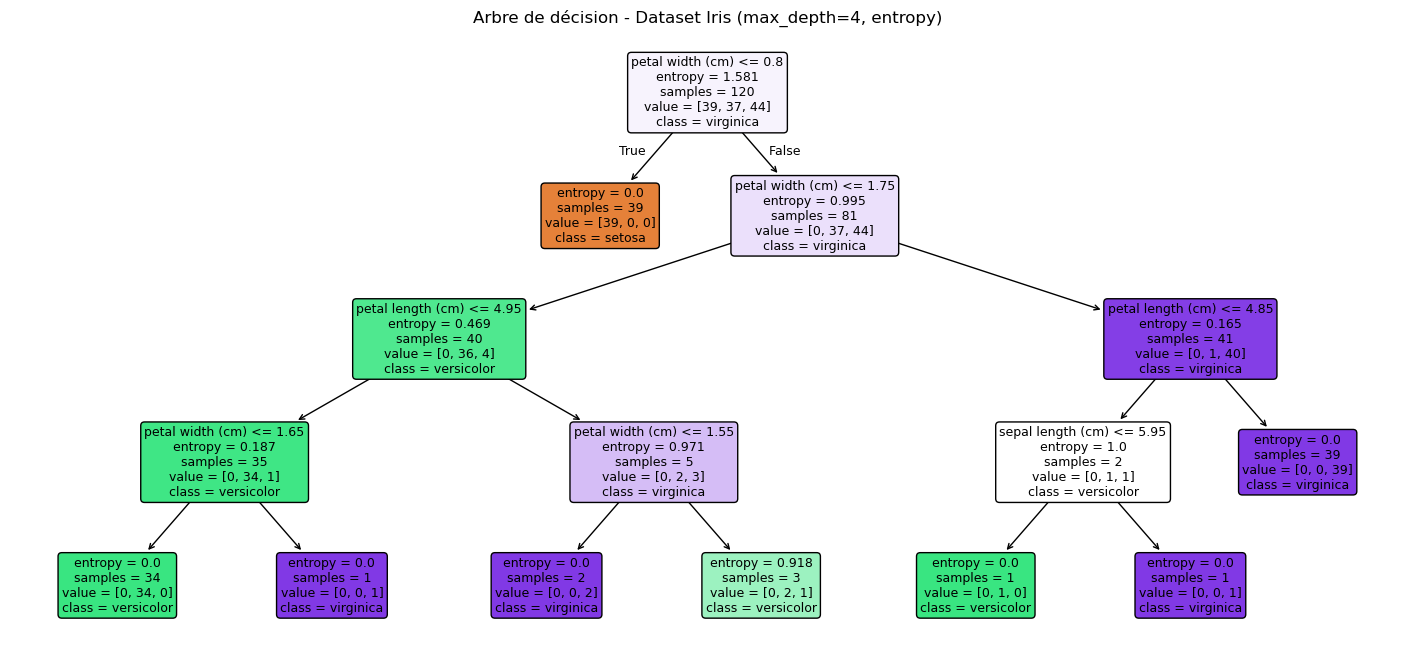

In [19]:
# Visualisation de l'arbre Iris
plt.figure(figsize=(18, 8))
plot_tree(
    clf_iris,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Arbre de décision - Dataset Iris (max_depth=4, entropy)")
plt.show()

In [ ]:
# Rapport de classification
y_pred_iris = clf_iris.predict(x_test_iris)
print("Rapport de classification :")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))

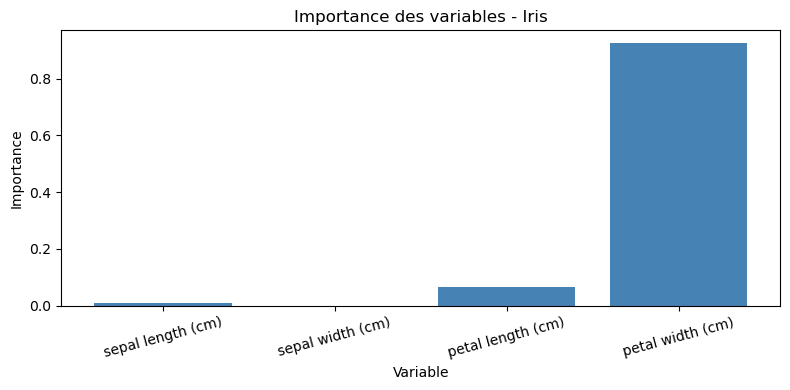

sepal length (cm): 0.0107
sepal width (cm): 0.0000
petal length (cm): 0.0649
petal width (cm): 0.9244


In [20]:
# Importance des variables (features)
importances = clf_iris.feature_importances_
feature_names = iris.feature_names

plt.figure(figsize=(8, 4))
plt.bar(feature_names, importances, color='steelblue')
plt.title("Importance des variables - Iris")
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for fname, imp in zip(feature_names, importances):
    print(f"{fname}: {imp:.4f}")

### Réponses Exercice 3

**Question 4 : Rapport de classification**

Le rapport de classification fournit pour chaque classe :
- **Precision** : parmi les prédictions positives, quelle fraction est correcte
- **Recall** : parmi les vrais positifs, quelle fraction est détectée
- **F1-score** : moyenne harmonique de la précision et du rappel
- **Support** : nombre d'exemples dans chaque classe

**Question 5 : Éviter le sur-apprentissage**

Pour éviter le **sur-apprentissage** d'un arbre de décision :
- Limiter la profondeur avec **`max_depth`**
- Imposer un nombre minimum d'échantillons par feuille avec **`min_samples_leaf`**
- Imposer un nombre minimum d'échantillons pour diviser un nœud avec **`min_samples_split`**
- Utiliser l'**élagage** (pruning) via `ccp_alpha`
- Utiliser la **validation croisée** pour sélectionner les hyperparamètres optimaux